# Weather Forecasting — Surabaya 2010–2020
**Final Project Machine Learning**  
Stasiun Meteorologi Perak I   
Klasifikasi: **Cerah / Berawan / Hujan**  
Fitur: **Tavg, RH_avg, RR, ss, ff_avg**  
Algoritma: **Decision Tree** & **K-Nearest Neighbors**

## 1. Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, accuracy_score,
                             precision_score, recall_score, f1_score)

import warnings
warnings.filterwarnings('ignore')
print("Library siap!")

Library siap!


## 2. Load Dataset

In [ ]:
# Upload file surabaya_climate.csv lalu jalankan cell ini
# from google.colab import files
# files.upload()

df_raw = pd.read_csv('surabaya_climate.csv')

print(f"Shape  : {df_raw.shape}")
print(f"Periode: {df_raw['date'].iloc[0]} hingga {df_raw['date'].iloc[-1]}")
df_raw.head()

Shape  : (4002, 12)
Periode: 01-01-2010 hingga 31-12-2020


,date,Tn,Tx,Tavg,RH_avg,RR,ss,ff_x,ddd_x,ff_avg,ddd_car,station_id
0,01-01-2010,25.0,33.1,28.8,78.0,3.0,0.2,3.0,NaN,3.0,NaN,96933
1,02-01-2010,25.7,34.8,29.3,77.0,NaN,0.5,4.0,NaN,4.0,NaN,96933
2,03-01-2010,25.8,35.4,29.7,74.0,0.0,0.5,5.0,NaN,4.0,NaN,96933
3,04-01-2010,25.6,33.3,28.9,68.0,3.8,0.1,5.0,NaN,3.0,NaN,96933
4,05-01-2010,23.8,33.8,28.1,83.0,51.0,0.3,3.0,NaN,2.0,NaN,96933


## 3. Inspeksi Data Awal

In [ ]:
FITUR = ['Tavg', 'ss', 'ff_avg']

print("=== Statistik Deskriptif ===")
print(df_raw[FITUR].describe().round(2))
print()
print("=== Jumlah NaN per Fitur ===")
nan_info = df_raw[FITUR].isnull().sum()
for col, n in nan_info.items():
    pct = n / len(df_raw) * 100
    print(f"  {col:8s}: {n:4d} baris ({pct:.1f}%)")

=== Statistik Deskriptif ===
          Tavg       ss   ff_avg
count  4000.00  3787.00  3663.00
mean     28.66     5.05     2.37
std       1.16     3.46     1.27
min      25.00     0.00     0.00
25%      27.80     1.00     1.00
50%      28.60     5.80     2.00
75%      29.40     8.00     3.00
max      32.80    11.20     7.00

=== Jumlah NaN per Fitur ===
  Tavg    :    2 baris (0.0%)
  ss      :  215 baris (5.4%)
  ff_avg  :  339 baris (8.5%)


## 4. Cleaning Data

In [ ]:
df = df_raw[['date', 'Tavg', 'ss', 'ff_avg', 'RH_avg', 'RR']].copy()

df['date'] = pd.to_datetime(df['date'], dayfirst=True)
df.replace([8888.0, 9999.0], np.nan, inplace=True)

print("NaN sebelum handling:")
print(df[['Tavg', 'ss', 'ff_avg', 'RH_avg', 'RR']].isnull().sum())

NaN sebelum handling:
Tavg        2
ss        215
ff_avg    339
RH_avg    338
RR        790
dtype: int64


In [ ]:
# Handling missing values
for col in ['Tavg', 'ss', 'ff_avg']:
    df[col].fillna(df[col].median(), inplace=True)

df['RH_avg'].fillna(df['RH_avg'].median(), inplace=True)
df['RR'].fillna(0.0, inplace=True)

print("NaN setelah handling:")
print(df[['Tavg', 'ss', 'ff_avg', 'RH_avg', 'RR']].isnull().sum())
print(f"\nTotal data bersih: {len(df)} baris")

NaN setelah handling:
Tavg      0
ss        0
ff_avg    0
RH_avg    0
RR        0
dtype: int64

Total data bersih: 4002 baris


## 5. Pembuatan Label Target

Aturan klasifikasi berdasarkan **RR** dan **RH_avg**:

| Kondisi | Label |
|---|---|
| RR > 5 mm **atau** RH_avg > 80% | **Hujan** |
| RR > 0 mm **atau** RH_avg > 65% | **Berawan** |
| Selainnya | **Cerah** |

In [ ]:
def buat_label(row):
    rr, rh = row['RR'], row['RH_avg']
    if rr > 5 or rh > 80:
        return 'Hujan'
    elif rr > 0 or rh > 65:
        return 'Berawan'
    else:
        return 'Cerah'

df['LABEL'] = df.apply(buat_label, axis=1)

print("=== Distribusi Label ===")
counts = df['LABEL'].value_counts()
print(counts)
print()
pct = df['LABEL'].value_counts(normalize=True).mul(100).round(1)
for k, v in pct.items():
    bar = '█' * int(v // 2)
    print(f"  {k:10s}: {v:5.1f}%  {bar}")

=== Distribusi Label ===
LABEL
Berawan    2316
Hujan      1261
Cerah       425
Name: count, dtype: int64

  Berawan   :  57.9%  ████████████████████████████
  Hujan     :  31.5%  ███████████████
  Cerah     :  10.6%  █████


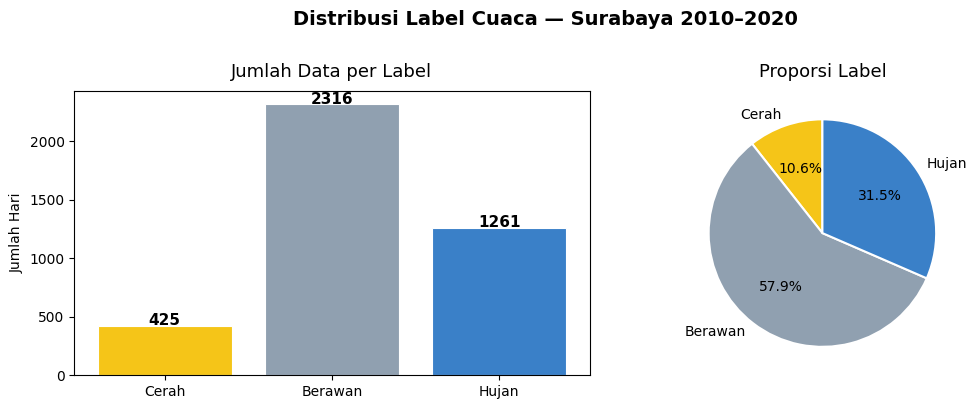

In [ ]:
# Visualisasi distribusi label
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
palette = {'Cerah': '#F5C518', 'Berawan': '#90A0B0', 'Hujan': '#3A80C8'}
order   = ['Cerah', 'Berawan', 'Hujan']
counts  = df['LABEL'].value_counts().reindex(order)

axes[0].bar(order, counts.values,
            color=[palette[l] for l in order],
            edgecolor='white', linewidth=0.8)
axes[0].set_title('Jumlah Data per Label', fontsize=13, pad=10)
axes[0].set_ylabel('Jumlah Hari')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center',
                 fontsize=11, fontweight='bold')

axes[1].pie(counts.values, labels=order,
            colors=[palette[l] for l in order],
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Proporsi Label', fontsize=13, pad=10)

plt.suptitle('Distribusi Label Cuaca — Surabaya 2010–2020',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('01_distribusi_label.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Eksplorasi Data (EDA)

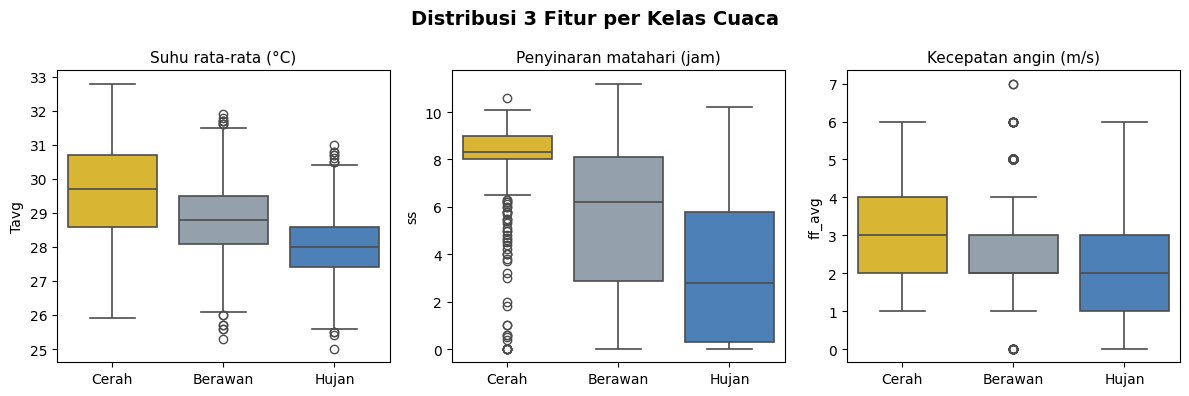

In [ ]:
# Boxplot 3 fitur per label
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
fitur_info = [
    ('Tavg',   'Suhu rata-rata (°C)'),
    ('ss',     'Penyinaran matahari (jam)'),
    ('ff_avg', 'Kecepatan angin (m/s)'),
]

for ax, (col, judul) in zip(axes, fitur_info):
    sns.boxplot(data=df, x='LABEL', y=col, order=order,
                palette=palette, ax=ax, linewidth=1.2)
    ax.set_title(judul, fontsize=11)
    ax.set_xlabel('')

plt.suptitle('Distribusi 3 Fitur per Kelas Cuaca',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('02_boxplot_fitur.png', dpi=150, bbox_inches='tight')
plt.show()

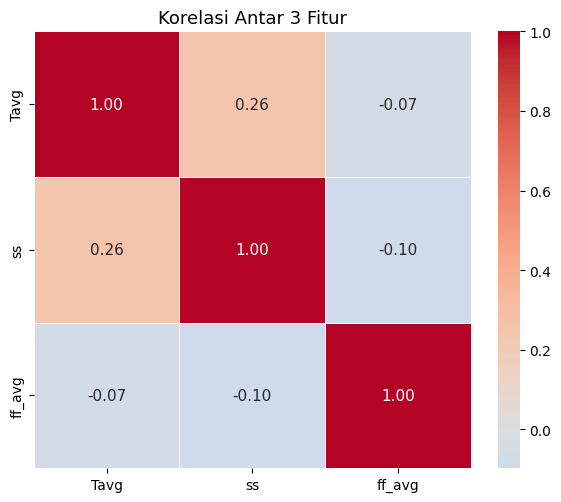

In [ ]:
# Heatmap korelasi 3 fitur
plt.figure(figsize=(6, 5))
corr = df[FITUR].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5,
            annot_kws={'size': 11})
plt.title('Korelasi Antar 3 Fitur', fontsize=13)
plt.tight_layout()
plt.savefig('03_korelasi_fitur.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Rata-rata tiap fitur per label (tabel ringkasan)
print("=== Rata-rata Nilai Fitur per Kelas ===")
summary = df.groupby('LABEL')[FITUR].mean().round(2)
print(summary.to_string())

=== Rata-rata Nilai Fitur per Kelas ===
          Tavg    ss  ff_avg
LABEL                       
Berawan  28.83  5.59    2.39
Cerah    29.60  7.99    2.84
Hujan    28.04  3.20    2.07


## 7. Normalisasi & Split Data

In [ ]:
X = df[FITUR].copy()
y = df['LABEL'].copy()

# MinMaxScaler — wajib untuk K-NN, opsional Decision Tree
scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=FITUR)

# 80% train / 20% test, stratify agar proporsi label seimbang
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Total data  : {len(X):,} baris")
print(f"Train       : {len(X_train):,} baris  ({len(X_train)/len(X)*100:.0f}%)")
print(f"Test        : {len(X_test):,} baris  ({len(X_test)/len(X)*100:.0f}%)")
print()
print("Distribusi label — Train:")
print(y_train.value_counts().to_string())
print()
print("Distribusi label — Test:")
print(y_test.value_counts().to_string())

Total data  : 4,002 baris
Train       : 3,201 baris  (80%)
Test        : 801 baris  (20%)

Distribusi label — Train:
LABEL
Berawan    1852
Hujan      1009
Cerah       340

Distribusi label — Test:
LABEL
Berawan    464
Hujan      252
Cerah       85


## 8. Modeling — Decision Tree

In [ ]:
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

acc_dt = accuracy_score(y_test, y_pred_dt)
print(f"Akurasi Decision Tree : {acc_dt*100:.2f}%")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_dt,
                            target_names=['Berawan', 'Cerah', 'Hujan']))

Akurasi Decision Tree : 70.04%

Classification Report:
              precision    recall  f1-score   support

     Berawan       0.69      0.87      0.77       464
       Cerah       0.80      0.19      0.30        85
       Hujan       0.71      0.56      0.62       252

    accuracy                           0.70       801
   macro avg       0.73      0.54      0.57       801
weighted avg       0.71      0.70      0.68       801



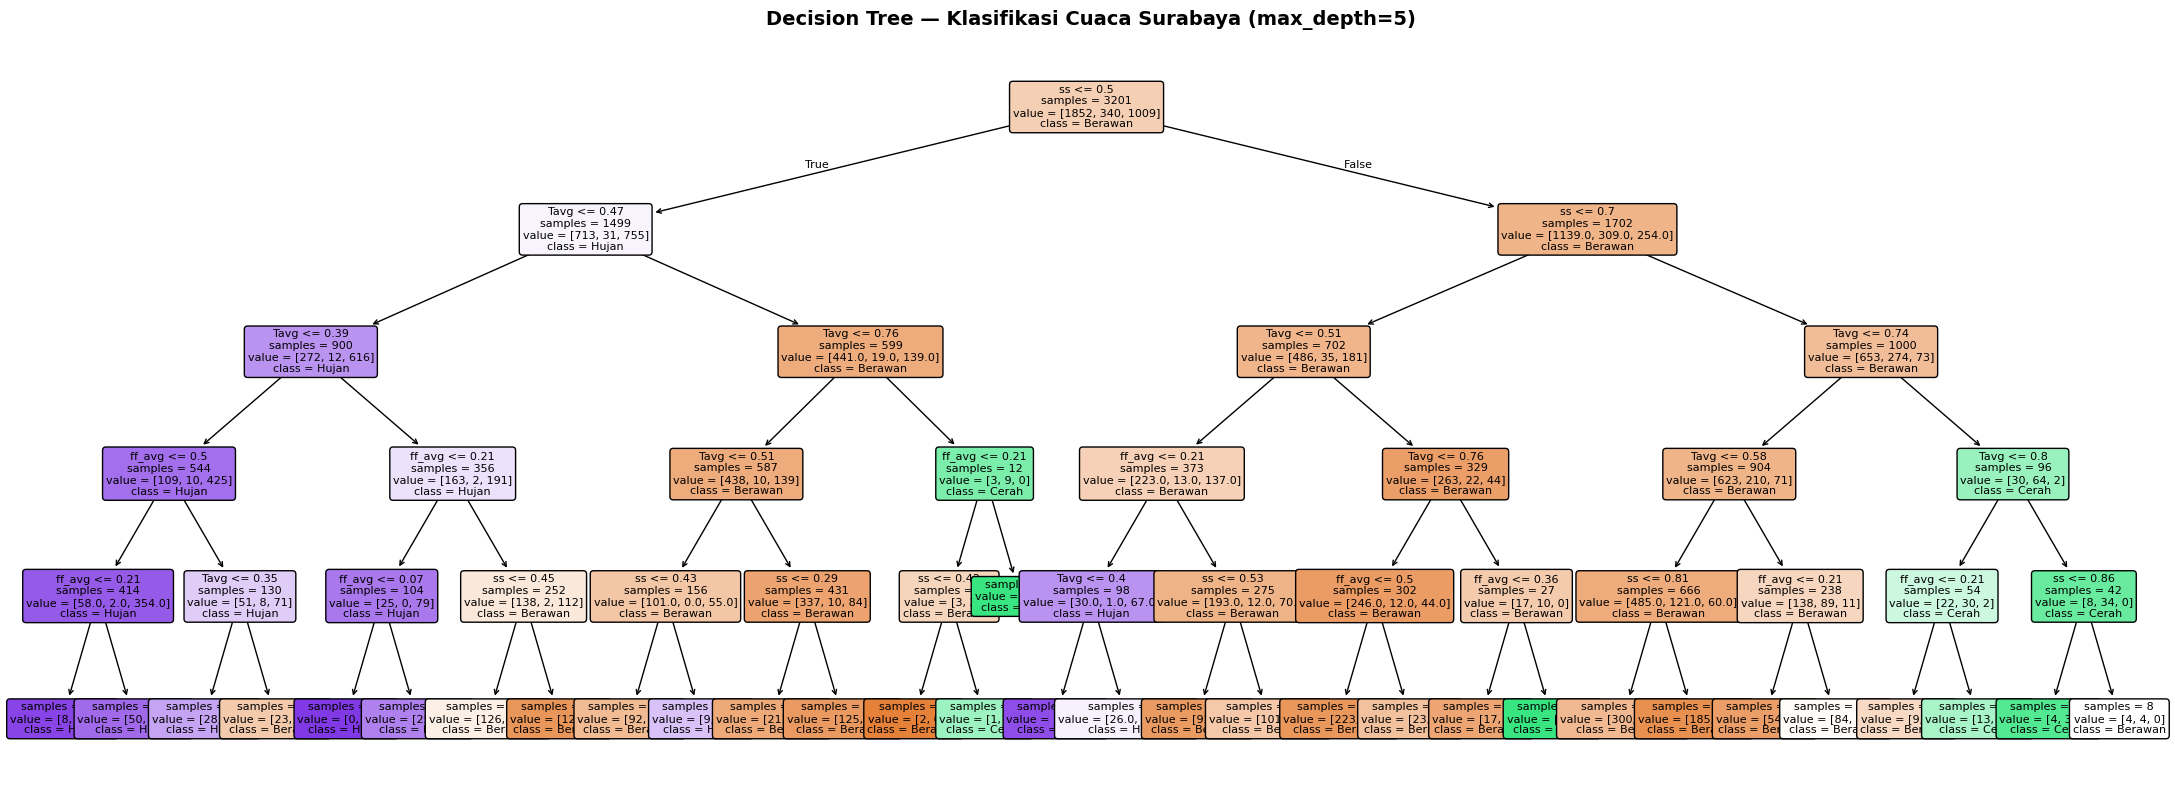


=== Aturan Pohon Keputusan (5 level pertama) ===
|--- ss <= 0.50
|   |--- Tavg <= 0.47
|   |   |--- Tavg <= 0.39
|   |   |   |--- ff_avg <= 0.50
|   |   |   |   |--- ff_avg <= 0.21
|   |   |   |   |   |--- class: Hujan
|   |   |   |   |--- ff_avg >  0.21
|   |   |   |   |   |--- class: Hujan
|   |   |   |--- ff_avg >  0.50
|   |   |   |   |--- Tavg <= 0.35
|   |   |   |   |   |--- class: Hujan
|   |   |   |   |--- Tavg >  0.35
|   |   |   |   |   |--- class: Berawan
|   |   |--- Tavg >  0.39
|   |   |   |--- ff_avg <= 0.21
|   |   |   |   |--- ff_avg <= 0.07
|   |   |   |   |   |--- class: Hujan
|   |   |   |   |--- ff_avg >  0.07
|   |   |   |   |   |--- class: Hujan
|   |   |   |--- ff_avg >  0.21
|   |   |   |   |--- ss <= 0.45
|   |   |   |   |   |--- class: Berawan
|   |   |   |   |--- ss >  0.45
|   |   |   |   |   |--- class: Berawan
|   |--- Tavg >  0.47
|   |   |--- Tavg <= 0.76
|   |   |   |--- Tavg <= 0.51
|   |   |   |   |--- ss <= 0.43
|   |   |   |   |   |--- class: Bera

In [ ]:
# Visualisasi pohon keputusan
plt.figure(figsize=(22, 8))
plot_tree(dt, feature_names=FITUR,
          class_names=['Berawan', 'Cerah', 'Hujan'],
          filled=True, rounded=True, fontsize=8,
          impurity=False, precision=2)
plt.title('Decision Tree — Klasifikasi Cuaca Surabaya (max_depth=5)',
          fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('04_decision_tree.png', dpi=120, bbox_inches='tight')
plt.show()

print("\n=== Aturan Pohon Keputusan (5 level pertama) ===")
print(export_text(dt, feature_names=FITUR, max_depth=5))

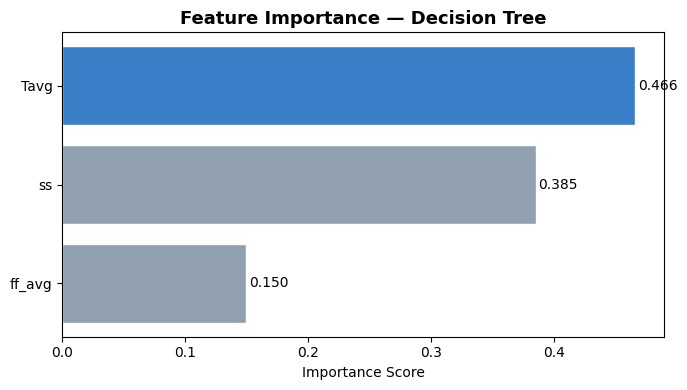

In [ ]:
# Feature importance Decision Tree
fi = pd.Series(dt.feature_importances_, index=FITUR).sort_values(ascending=True)

plt.figure(figsize=(7, 4))
colors = ['#3A80C8' if v == fi.max() else '#90A0B0' for v in fi.values]
plt.barh(fi.index, fi.values, color=colors, edgecolor='white')
plt.xlabel('Importance Score')
plt.title('Feature Importance — Decision Tree', fontsize=13, fontweight='bold')
for i, v in enumerate(fi.values):
    plt.text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('05_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

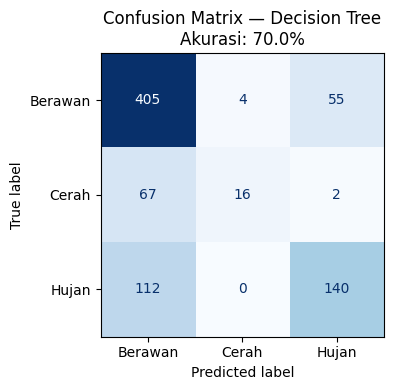

In [ ]:
# Confusion matrix Decision Tree
fig, ax = plt.subplots(figsize=(5, 4))
cm_dt = confusion_matrix(y_test, y_pred_dt,
                         labels=['Berawan', 'Cerah', 'Hujan'])
disp = ConfusionMatrixDisplay(cm_dt,
                              display_labels=['Berawan', 'Cerah', 'Hujan'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix — Decision Tree\nAkurasi: {acc_dt*100:.1f}%',
             fontsize=12)
plt.tight_layout()
plt.savefig('06_cm_decision_tree.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Modeling — K-Nearest Neighbors

In [ ]:
# Cari K terbaik dengan cross-validation (K ganjil 1–21)
k_values = range(1, 22, 2)
k_scores = []

print("Mencari K terbaik...")
for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    scores = cross_val_score(knn_temp, X_train, y_train,
                             cv=5, scoring='accuracy')
    k_scores.append(scores.mean())
    print(f"  K={k:2d}  ->  CV Accuracy: {scores.mean()*100:.2f}%")

best_k = list(k_values)[np.argmax(k_scores)]
print(f"\nK terbaik: {best_k}  (Accuracy: {max(k_scores)*100:.2f}%)")

Mencari K terbaik...
  K= 1  ->  CV Accuracy: 62.39%
  K= 3  ->  CV Accuracy: 67.92%
  K= 5  ->  CV Accuracy: 69.10%
  K= 7  ->  CV Accuracy: 69.17%
  K= 9  ->  CV Accuracy: 70.35%
  K=11  ->  CV Accuracy: 70.88%
  K=13  ->  CV Accuracy: 70.66%
  K=15  ->  CV Accuracy: 70.82%
  K=17  ->  CV Accuracy: 71.51%
  K=19  ->  CV Accuracy: 70.98%
  K=21  ->  CV Accuracy: 71.29%

K terbaik: 17  (Accuracy: 71.51%)


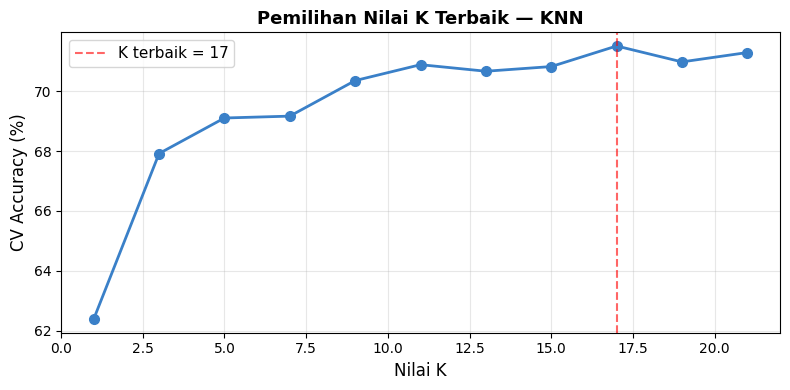

In [ ]:
# Plot K vs Accuracy
plt.figure(figsize=(8, 4))
plt.plot(list(k_values), [s * 100 for s in k_scores],
         marker='o', color='#3A80C8', linewidth=2, markersize=7)
plt.axvline(best_k, color='red', linestyle='--', alpha=0.6,
            label=f'K terbaik = {best_k}')
plt.xlabel('Nilai K', fontsize=12)
plt.ylabel('CV Accuracy (%)', fontsize=12)
plt.title('Pemilihan Nilai K Terbaik — KNN', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('07_knn_k_selection.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Train KNN dengan K terbaik
knn = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean')
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

acc_knn = accuracy_score(y_test, y_pred_knn)
print(f"Akurasi K-NN (K={best_k}) : {acc_knn*100:.2f}%")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_knn,
                            target_names=['Berawan', 'Cerah', 'Hujan']))

Akurasi K-NN (K=17) : 72.41%

Classification Report:
              precision    recall  f1-score   support

     Berawan       0.72      0.86      0.79       464
       Cerah       0.76      0.34      0.47        85
       Hujan       0.73      0.60      0.66       252

    accuracy                           0.72       801
   macro avg       0.74      0.60      0.64       801
weighted avg       0.73      0.72      0.71       801



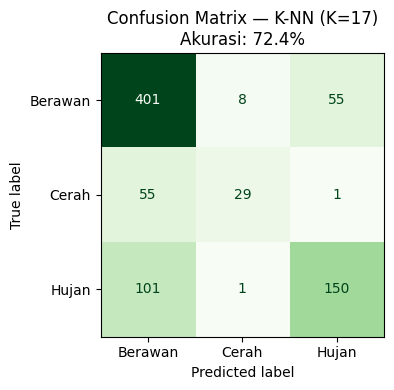

In [ ]:
# Confusion matrix KNN
fig, ax = plt.subplots(figsize=(5, 4))
cm_knn = confusion_matrix(y_test, y_pred_knn,
                          labels=['Berawan', 'Cerah', 'Hujan'])
disp = ConfusionMatrixDisplay(cm_knn,
                              display_labels=['Berawan', 'Cerah', 'Hujan'])
disp.plot(ax=ax, colorbar=False, cmap='Greens')
ax.set_title(f'Confusion Matrix — K-NN (K={best_k})\nAkurasi: {acc_knn*100:.1f}%',
             fontsize=12)
plt.tight_layout()
plt.savefig('08_cm_knn.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Perbandingan Decision Tree vs K-NN

In [ ]:
def get_metrics(y_true, y_pred, name):
    return {
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_true, y_pred) * 100, 2),
        'Precision': round(precision_score(y_true, y_pred,
                           average='weighted') * 100, 2),
        'Recall'   : round(recall_score(y_true, y_pred,
                           average='weighted') * 100, 2),
        'F1-Score' : round(f1_score(y_true, y_pred,
                           average='weighted') * 100, 2),
    }

hasil = pd.DataFrame([
    get_metrics(y_test, y_pred_dt,  f'Decision Tree (depth=5)'),
    get_metrics(y_test, y_pred_knn, f'K-NN (K={best_k})'),
])

print("=== Perbandingan Performa Model ===")
print(hasil.to_string(index=False))
print()
pemenang = hasil.loc[hasil['Accuracy'].idxmax(), 'Model']
print(f"Model terbaik berdasarkan Accuracy: {pemenang}")

=== Perbandingan Performa Model ===
                  Model  Accuracy  Precision  Recall  F1-Score
Decision Tree (depth=5)     70.04      71.02   70.04     67.63
            K-NN (K=17)     72.41      72.71   72.41     71.11

Model terbaik berdasarkan Accuracy: K-NN (K=17)


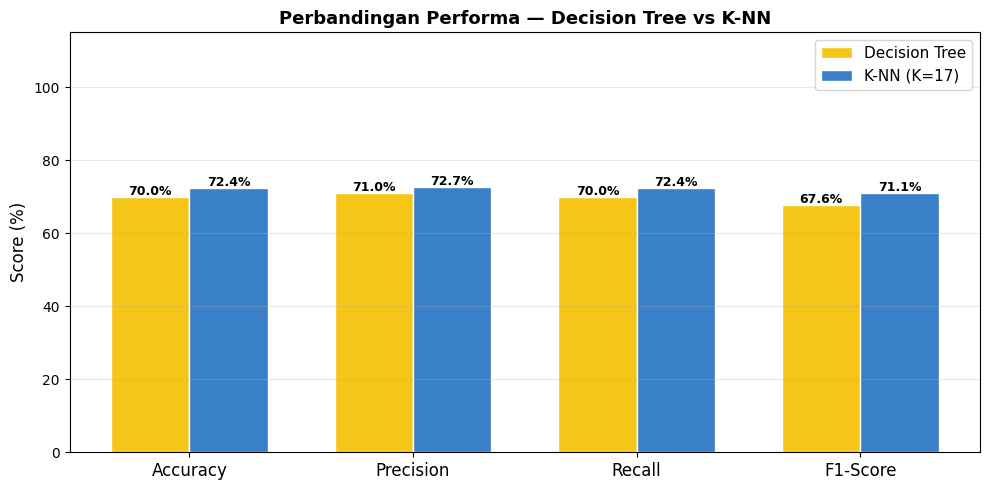

In [ ]:
# Grafik perbandingan 4 metrik
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - w / 2, hasil.iloc[0][metrics], w,
            label='Decision Tree', color='#F5C518', edgecolor='white')
b2 = ax.bar(x + w / 2, hasil.iloc[1][metrics], w,
            label=f'K-NN (K={best_k})', color='#3A80C8', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0, 115)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('Perbandingan Performa — Decision Tree vs K-NN',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

for bar in [*b1, *b2]:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.5,
            f'{h:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('09_perbandingan_model.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Prediksi Cuaca Baru

In [ ]:
# Ganti nilai sesuai kondisi yang ingin diprediksi
# Urutan kolom: Tavg, RH_avg, RR, ss, ff_avg
# Urutan kolom: Tavg, ss, ff_avg
data_baru = pd.DataFrame({
    'Tavg'  : [29.5, 27.0, 32.0],
    'ss'    : [7.5,   0.5,  9.0],
    'ff_avg': [2.0,   4.0,  1.5],
}, columns=FITUR)

data_baru_scaled = pd.DataFrame(
    scaler.transform(data_baru), columns=FITUR
)

pred_dt  = dt.predict(data_baru_scaled)
pred_knn = knn.predict(data_baru_scaled)

data_baru['Prediksi_DT']  = pred_dt
data_baru['Prediksi_KNN'] = pred_knn

print("=== Hasil Prediksi Data Baru ===")
print(data_baru.to_string(index=False))

=== Hasil Prediksi Data Baru ===
 Tavg  ss  ff_avg Prediksi_DT Prediksi_KNN
 29.5 7.5     2.0     Berawan      Berawan
 27.0 0.5     4.0       Hujan      Berawan
 32.0 9.0     1.5       Cerah        Cerah


## 12. Simpan Data & Model

In [ ]:
import joblib

df.to_csv('data_clean_surabaya.csv', index=False)
joblib.dump(dt,     'model_decision_tree.pkl')
joblib.dump(knn,    'model_knn.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("File tersimpan:")
print("  data_clean_surabaya.csv  — data bersih + label")
print("  model_decision_tree.pkl  — model Decision Tree")
print("  model_knn.pkl            — model K-NN")
print("  scaler.pkl               — MinMaxScaler")
print()
print("=== Ringkasan Akhir ===")
print(f"Total data        : {len(df):,} baris")
print(f"Fitur             : {FITUR}")
print(f"Periode           : 2010–2020")
print(f"Akurasi DT        : {acc_dt*100:.2f}%")
print(f"Akurasi KNN (K={best_k}) : {acc_knn*100:.2f}%")

File tersimpan:
  data_clean_surabaya.csv  — data bersih + label
  model_decision_tree.pkl  — model Decision Tree
  model_knn.pkl            — model K-NN
  scaler.pkl               — MinMaxScaler

=== Ringkasan Akhir ===
Total data        : 4,002 baris
Fitur             : ['Tavg', 'ss', 'ff_avg']
Periode           : 2010–2020
Akurasi DT        : 70.04%
Akurasi KNN (K=17) : 72.41%
